<a href="https://colab.research.google.com/github/channelable/IHub_AIML_Training_Program/blob/main/AIML_Module_5_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regression Lab 2: Loss Functions


## Motivation

The main goal of machine learning tasks is to "learn" something about data we feed to our models. But how does the model actually learn anything? To understand this, we need to first understand what objective functions are.

Mathematically, objective functions are a function whose values we desire to minimize/maximize. In the context of machine learning, the objective is commonly referred to as a **loss function**. Loss functions indicate how well the model is doing on the dataset.

The value of the objective function is simply called **loss**. Our goal is to eventually find the best model parameters that has the least average loss on the data after training.


We are familiar with the idea of **error** from the linear regression lab. RMSE is a common loss function used in machine learning. However, there are many other loss functions employed, depending on what the task is (classification, regression etc.). In this lab, we will take a look at some common loss functions, and understand why they are used where they are.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# interactive visualization

# 1. Regression


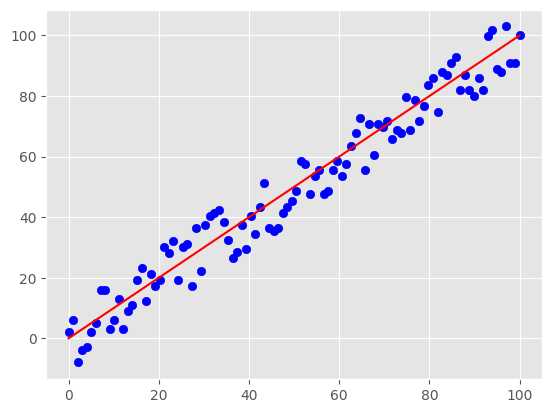

In [ ]:
# initializing random data

np.random.seed(0)
x = np.linspace(0,100,100)
y_actual = np.copy(x)
y_pred = x + np.random.randint(-10,10,100)

plt.plot(x,y_actual,color="red")
plt.scatter(x,y_pred,color="blue")
plt.show()

### Mean Squared Error

As we have seen before, the formula for MSE is

$MSE = \frac{1}{m} \sum_{i=1}^n (y-y_p)^2$

The image below depicts a visualization of what the squared error is.

<img src="https://drive.google.com/uc?export=view&id=12jmqRrrqknIWKhwRpgRIJAErBjkEcyx9" width="350" height="350" align="middle"/>

MSE is also referred to as L2 loss.

Typically, we would want the units of error to be the same as the data, so we use Root Mean Squared Error instead.



In [ ]:
mse = np.mean((y_actual-y_pred)**2)
print("MSE is: {}".format(mse))
print("RMSE is: {}".format(np.sqrt(mse)))

MSE is: 38.68
RMSE is: 6.219324722186485


### Mean Absolute Error

$MAE = \frac{1}{m} \sum_{i=1}^n |y-y_p|$

MAE is also commonly referred to as L1 loss.

In [ ]:
mae = np.mean(np.abs(y_actual-y_pred))
print("MAE is: {}".format(mae))

MAE is: 5.5


MSE penalizes the model for making large errors by squaring the difference. However, this also means that MSE cannot handle outliers well, since they would throw the model off.

On the other hand, MAE is robust to outliers. But, MAE is non-differentiable, making it difficult to perform mathematical operations on it.

Hence, RMSE is most commonly used as a metric for evaluation.

# 2. Classification

Classification tasks involve some data, along with labels assigned to that data. For example, we may have pictures of cats and dogs, and the corresponding labels assigned to those images. We then want to train a model that can predict a label for some input image belonging to either label class (cat or dog).

## The concept of maximum likelihood

Ideally, we would want to obtain a model $\hat{\theta}$ which maximizes the probability of correctly predicting data. Mathematically, the likelihood is:

$ \prod_{i=1}^{N}  \: \hat{\theta_i}^{\theta_i}$

This is because our actual data ($\theta_i$) is either 0 or 1 depending on the label of the data, and our predicted data ($\hat{\theta_i}$) is a probability.

We usually consider the negative log of the likelihood, since log is monotonic and easier to deal with as an optimization problem.

Hence, we have

$MLE = $ arg min $\: - \sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$

\


## Entropy and Cross-Entropy

For some event $x$, we can obtain **information** based on its probability distribution. For example, for some event that occurs with $p=1$, we gain no information. Now, if we flip a coin and see that we obtained heads, we say that we got 1 bit of information.

Thus, the information $I$ of some event $x$ is:

$I = -log_2 \: p(x)$

We say that events with a low probability of occuring give high information, and those with a low probability give low information.

Now, if we have some random variable $X$, its **entropy** is the expected value of the information obtained.

$H(x) = - \sum_{k} p_k \: log \: p_k$

Now, suppose we are trying to correctly predict labels of some data. Let P be the true distribution of the labels, and Q be the predicted distribution of labels.

Cross-Entropy is then defined as:

$H(P,Q) = - \sum_{x} P(x)\: log \: Q(x)$

which is basically the entropy between two probability distributions over the same events.

\


## MLE and Cross-Entropy

So, in the case of classification, the equation for minimization of the cross-entropy between the actual data and the predicted data would be:

arg min $\: -\sum_{i=1}^{N} P(x) \: log \: Q(x)$

$= $ arg min $\: -\sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$


which is exactly the same as what we had obtained for minimizing the negative log likelihood. Hence, the two problems are equivalent.

1/1+e^(-x)

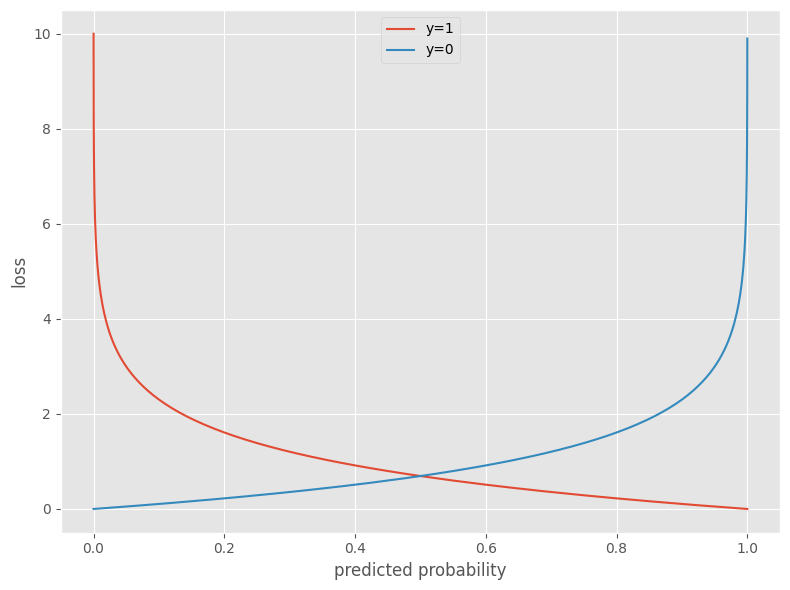

In [ ]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def cross_entropy_loss(y_,y):
  if y==1:
    return -np.log(y_)

  return -np.log(1-y_)

z = np.arange(-10, 10, 0.1)
h_z = sigmoid(z)

cost_1 = cross_entropy_loss(h_z, 1)
cost_0 = cross_entropy_loss(h_z, 0)

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(h_z, cost_1, label='y=1')
plt.plot(h_z, cost_0, label='y=0')
plt.xlabel('predicted probability')
plt.ylabel('loss')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## KNN-regression

Till now, we have studied KNN as a classification algorithm, which uses feature similarity and voting to decide the class labels of unseen data.

For regression, we use the same idea: We take the y-values of the k nearest neighbours, and compute their average, which is our predicted y-value. We do this for every x whose value we want to predict.

In the visualization below, we have k=3, and the red dots are the new x-values whose output we want to predict.

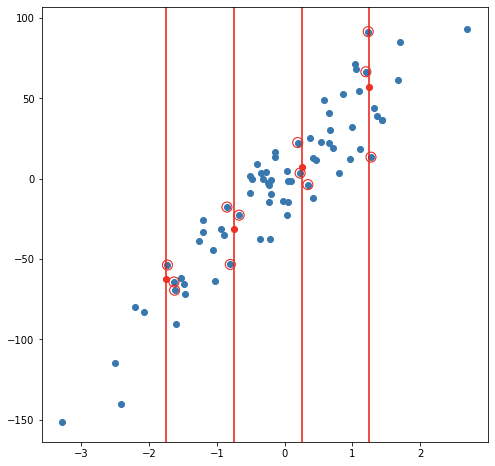

In [ ]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:
# Load the BigMart dataset.
# The original lab uses the public GitHub CSV. If it is unavailable, use a small
# reproducible fallback dataset so the KNN-regression exercise can still run.
train_path = "https://raw.githubusercontent.com/PranavTadimeti/Regression-lab2/main/BigMart-train.csv"

try:
    train = pd.read_csv(train_path)
    print("Loaded BigMart dataset:", train.shape)
except Exception as e:
    print("BigMart dataset could not be downloaded in this environment.")
    print("Using a reproducible regression fallback dataset instead.")
    rng = np.random.default_rng(42)
    n = 1200
    train = pd.DataFrame({
        "Item_Weight": rng.normal(12.8, 4.5, n).clip(2, 25),
        "Item_Fat_Content": rng.choice(["Low Fat", "Regular"], n),
        "Item_Visibility": rng.uniform(0, 0.3, n),
        "Item_MRP": rng.uniform(30, 270, n),
        "Outlet_Establishment_Year": rng.integers(1985, 2010, n),
        "Outlet_Size": rng.choice(["Small", "Medium", "High"], n),
        "Outlet_Location_Type": rng.choice(["Tier 1", "Tier 2", "Tier 3"], n),
        "Outlet_Type": rng.choice(["Grocery Store", "Supermarket Type1", "Supermarket Type2"], n),
        "Item_Identifier": [f"ITEM{i}" for i in range(n)],
        "Outlet_Identifier": [f"OUT{i%10}" for i in range(n)]
    })
    train["Item_Outlet_Sales"] = (
        100 + 2.8*train["Item_MRP"] + 1800*train["Item_Visibility"]
        + 45*train["Item_Weight"]
        + rng.normal(0, 250, n)
    ).clip(0)
    train.loc[rng.choice(n, 40, replace=False), "Item_Weight"] = np.nan
    train.loc[rng.choice(n, 40, replace=False), "Outlet_Size"] = np.nan

BigMart dataset could not be downloaded in this environment.
Using a reproducible regression fallback dataset instead.


In [ ]:
# Preprocess Data
def preprocess(df):
    df = df.copy()
    mean_weight = df['Item_Weight'].mean()
    df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

    mode_size = df['Outlet_Size'].mode(dropna=True)
    if len(mode_size) > 0:
        df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size.iloc[0])

    df.drop(['Item_Identifier','Outlet_Identifier'], axis=1, inplace=True)
    return pd.get_dummies(df, dtype=int)

train = preprocess(train)
train.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2
0,14.171227,0.000170,178.268625,1997,1885.551148,1,0,1,0,0,0,1,0,0,1,0
1,8.120072,0.129584,31.196392,1994,1150.321488,1,0,0,0,1,0,0,1,0,0,1
2,16.177030,0.230773,74.234401,2005,1629.001222,1,0,0,1,0,0,1,0,1,0,0
3,17.032541,0.220040,182.529910,2006,1835.912608,1,0,0,0,1,1,0,0,1,0,0
4,4.020342,0.009645,121.132638,1996,678.377833,0,1,1,0,0,1,0,0,0,0,1


In [ ]:
train , test = train_test_split(train, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)

# Use transform (not fit_transform) on the test set to avoid data leakage.
x_test_scaled = scaler.transform(x_test)
x_test = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

In [ ]:
def knn_regression(k,x_train,y_train,x_test,y_test):
    model = neighbors.KNeighborsRegressor(n_neighbors = k)

    model.fit(x_train, y_train)
    pred=model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)

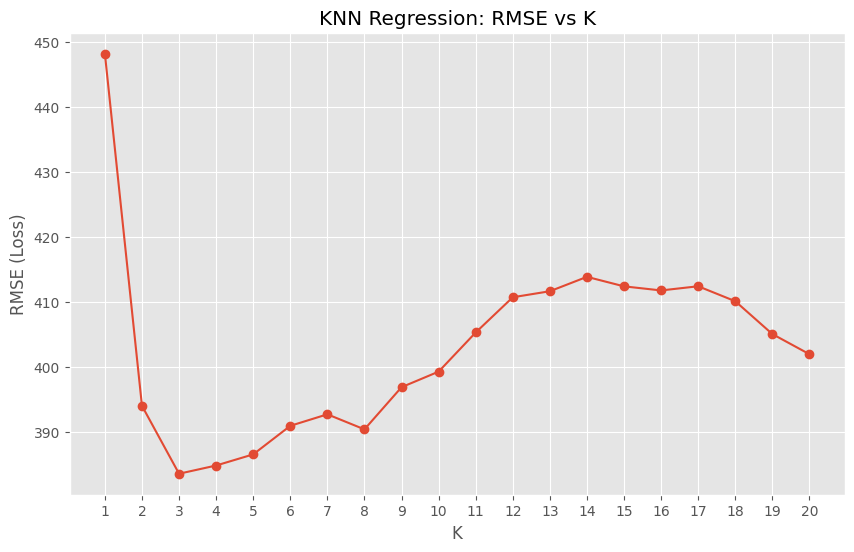

Minimum RMSE = 383.586 at k = 3


In [ ]:
rmse_val = []

for k in range(1, 21):
    knn_regression(k, x_train, y_train, x_test, y_test)

figure = plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 21), rmse_val, marker='o')
plt.xlabel("K")
plt.ylabel("RMSE (Loss)")
plt.title("KNN Regression: RMSE vs K")
plt.xticks(np.arange(1, 21))
plt.show()

rmse_val = np.asarray(rmse_val)
best_k = np.argmin(rmse_val) + 1
print("Minimum RMSE = {:.3f} at k = {}".format(np.min(rmse_val), best_k))

## Exercises

1. Try out these loss functions on regression tasks, and try to understand the model performance based on the loss function.
2. Explore other loss functions and try to understand when and why they are used.
3. Try out KNN-regression on other datasets see which values of K give the best results.
4. Try exploring what will happen if K is set to 1 or K is set to size of whole training dataset.

## Exercise Solutions

The following cells implement and answer all four exercises.

## References ##
1. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
2. https://www.geeksforgeeks.org/k-nearest-neighbours/
3. https://bookdown.org/tpinto_home/Regression-and-Classification/k-nearest-neighbours-regression.html#:~:text=KNN%20regression%20is%20a%20non,observations%20in%20the%20same%20neighbourhood

Good predictions: {'MSE': 0.9, 'RMSE': np.float64(0.9486832980505138), 'MAE': 0.9}
With one large outlier: {'MSE': 123.3, 'RMSE': np.float64(11.104053313993049), 'MAE': 4.3}


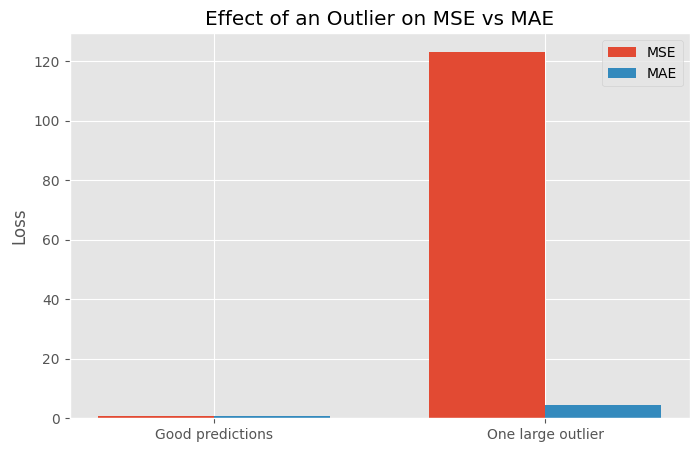

Observation: MSE/RMSE increase much more strongly when a large error is introduced because the error is squared.
MAE is more robust to outliers because it grows linearly with the absolute error.


In [ ]:
from sklearn.metrics import mean_absolute_error

# Exercise 1 — Compare regression loss functions
# Use the same predictions so that MSE/RMSE and MAE can be compared directly.

y_true = np.array([10, 12, 15, 18, 20, 25, 30, 35, 40, 45], dtype=float)
y_good = np.array([10, 13, 14, 19, 21, 24, 29, 36, 41, 44], dtype=float)
y_outlier = y_good.copy()
y_outlier[-1] = 80

def regression_losses(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

print("Good predictions:", regression_losses(y_true, y_good))
print("With one large outlier:", regression_losses(y_true, y_outlier))

labels = ["Good predictions", "One large outlier"]
mse_vals = [regression_losses(y_true, y_good)["MSE"],
            regression_losses(y_true, y_outlier)["MSE"]]
mae_vals = [regression_losses(y_true, y_good)["MAE"],
            regression_losses(y_true, y_outlier)["MAE"]]

xpos = np.arange(2)
width = 0.35
plt.figure(figsize=(8,5))
plt.bar(xpos-width/2, mse_vals, width, label="MSE")
plt.bar(xpos+width/2, mae_vals, width, label="MAE")
plt.xticks(xpos, labels)
plt.ylabel("Loss")
plt.title("Effect of an Outlier on MSE vs MAE")
plt.legend()
plt.show()

print("Observation: MSE/RMSE increase much more strongly when a large error is introduced because the error is squared.")
print("MAE is more robust to outliers because it grows linearly with the absolute error.")


In [ ]:
# Exercise 2 — Other useful regression loss functions
# Huber loss combines MAE-like robustness with MSE-like differentiability near zero.

def huber_loss(y_true, y_pred, delta=1.0):
    error = np.asarray(y_true) - np.asarray(y_pred)
    abs_error = np.abs(error)
    quadratic = np.minimum(abs_error, delta)
    linear = abs_error - quadratic
    return np.mean(0.5 * quadratic**2 + delta * linear)

preds = {
    "Good": y_good,
    "Outlier": y_outlier
}
for name, pred in preds.items():
    print(f"{name}: Huber={huber_loss(y_true, pred):.3f}, MAE={mean_absolute_error(y_true,pred):.3f}, RMSE={np.sqrt(mean_squared_error(y_true,pred)):.3f}")

print("\nOther common regression losses:")
print("• Huber: useful when data contain some outliers but we still want a smooth, differentiable loss.")
print("• Log-Cosh: behaves approximately like MSE for small errors and like MAE for large errors; useful when smoothness and robustness are both desired.")
print("• Quantile loss: useful when predicting a conditional quantile rather than the conditional mean, e.g. prediction intervals.")


Good: Huber=0.450, MAE=0.900, RMSE=0.949
Outlier: Huber=3.850, MAE=4.300, RMSE=11.104

Other common regression losses:
• Huber: useful when data contain some outliers but we still want a smooth, differentiable loss.
• Log-Cosh: behaves approximately like MSE for small errors and like MAE for large errors; useful when smoothness and robustness are both desired.
• Quantile loss: useful when predicting a conditional quantile rather than the conditional mean, e.g. prediction intervals.


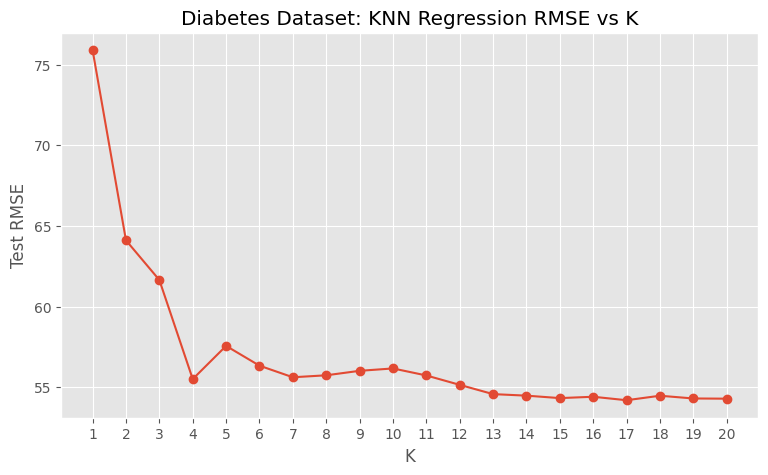

Best K on this train/test split: 17
Minimum test RMSE: 54.205
The exact best K can change with the train/test split; cross-validation is preferable for model selection.


In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import load_diabetes
# Exercise 3 — KNN regression on another dataset
# Use sklearn's diabetes regression dataset and evaluate K = 1..20.

diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

diabetes_rmse = []
for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    diabetes_rmse.append(np.sqrt(mean_squared_error(y_test, pred)))

best_k_diabetes = np.argmin(diabetes_rmse) + 1

plt.figure(figsize=(9,5))
plt.plot(range(1,21), diabetes_rmse, marker='o')
plt.xlabel("K")
plt.ylabel("Test RMSE")
plt.title("Diabetes Dataset: KNN Regression RMSE vs K")
plt.xticks(range(1,21))
plt.show()

print("Best K on this train/test split:", best_k_diabetes)
print("Minimum test RMSE:", round(diabetes_rmse[best_k_diabetes-1], 3))
print("The exact best K can change with the train/test split; cross-validation is preferable for model selection.")


In [ ]:
# Exercise 4 — What happens at K=1 and K=n?

n_train = len(X_train_s)

for k in [1, n_train]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    print(f"K={k}: Test RMSE = {np.sqrt(mean_squared_error(y_test, pred)):.3f}")

print("\nInterpretation:")
print("• K=1 uses only the single nearest training example. It is highly flexible and sensitive to noise, so it can have low training error but high variance.")
print("• K=n uses every training example for every prediction, so the prediction is essentially the global mean of y_train. It has very low variance but high bias and usually underfits.")


K=1: Test RMSE = 75.890


K=309: Test RMSE = 73.708

Interpretation:
• K=1 uses only the single nearest training example. It is highly flexible and sensitive to noise, so it can have low training error but high variance.
• K=n uses every training example for every prediction, so the prediction is essentially the global mean of y_train. It has very low variance but high bias and usually underfits.


### Exercise conclusions

1. **Loss functions and performance:** MSE/RMSE strongly penalize large errors, while MAE is less sensitive to outliers. The choice of loss should match the business/scientific cost of errors.
2. **Other loss functions:** Huber is a useful compromise between MSE and MAE; Log-Cosh is a smooth robust alternative; Quantile loss is appropriate when estimating conditional quantiles.
3. **Other KNN-regression datasets:** On the included diabetes example, test RMSE was evaluated for K=1–20 and the best K was selected from that curve. The exact value depends on the split and scaling.
4. **Extreme K values:** K=1 gives a highly local, high-variance model. K equal to the whole training set predicts approximately the training-set mean for every test point, producing a very smooth/high-bias model.
